This is a simple notebook to generate linear data with some (non-Gaussian) scatter, and do linear fits with different loss functions.
It accompanies Chapter 5 of the book (1 of 5).  
Copyright: Viviana Acquaviva (2023)  
Modified by Aaron Romanowsky.  
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model #New!

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

#### We begin by generating some data.

In [ ]:
np.random.seed(16) #set seed for reproducibility purposes

x = np.arange(100) 

y = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) #generate some data with scatter following Poisson distribution 
                                                    #with exp value = y from linear model, centered around 0

Note that the errors here are *not* well behaved as one would need to model for parameter inference, but it doesn't matter for predictive machine learning.

Text(0, 0.5, '$y$')

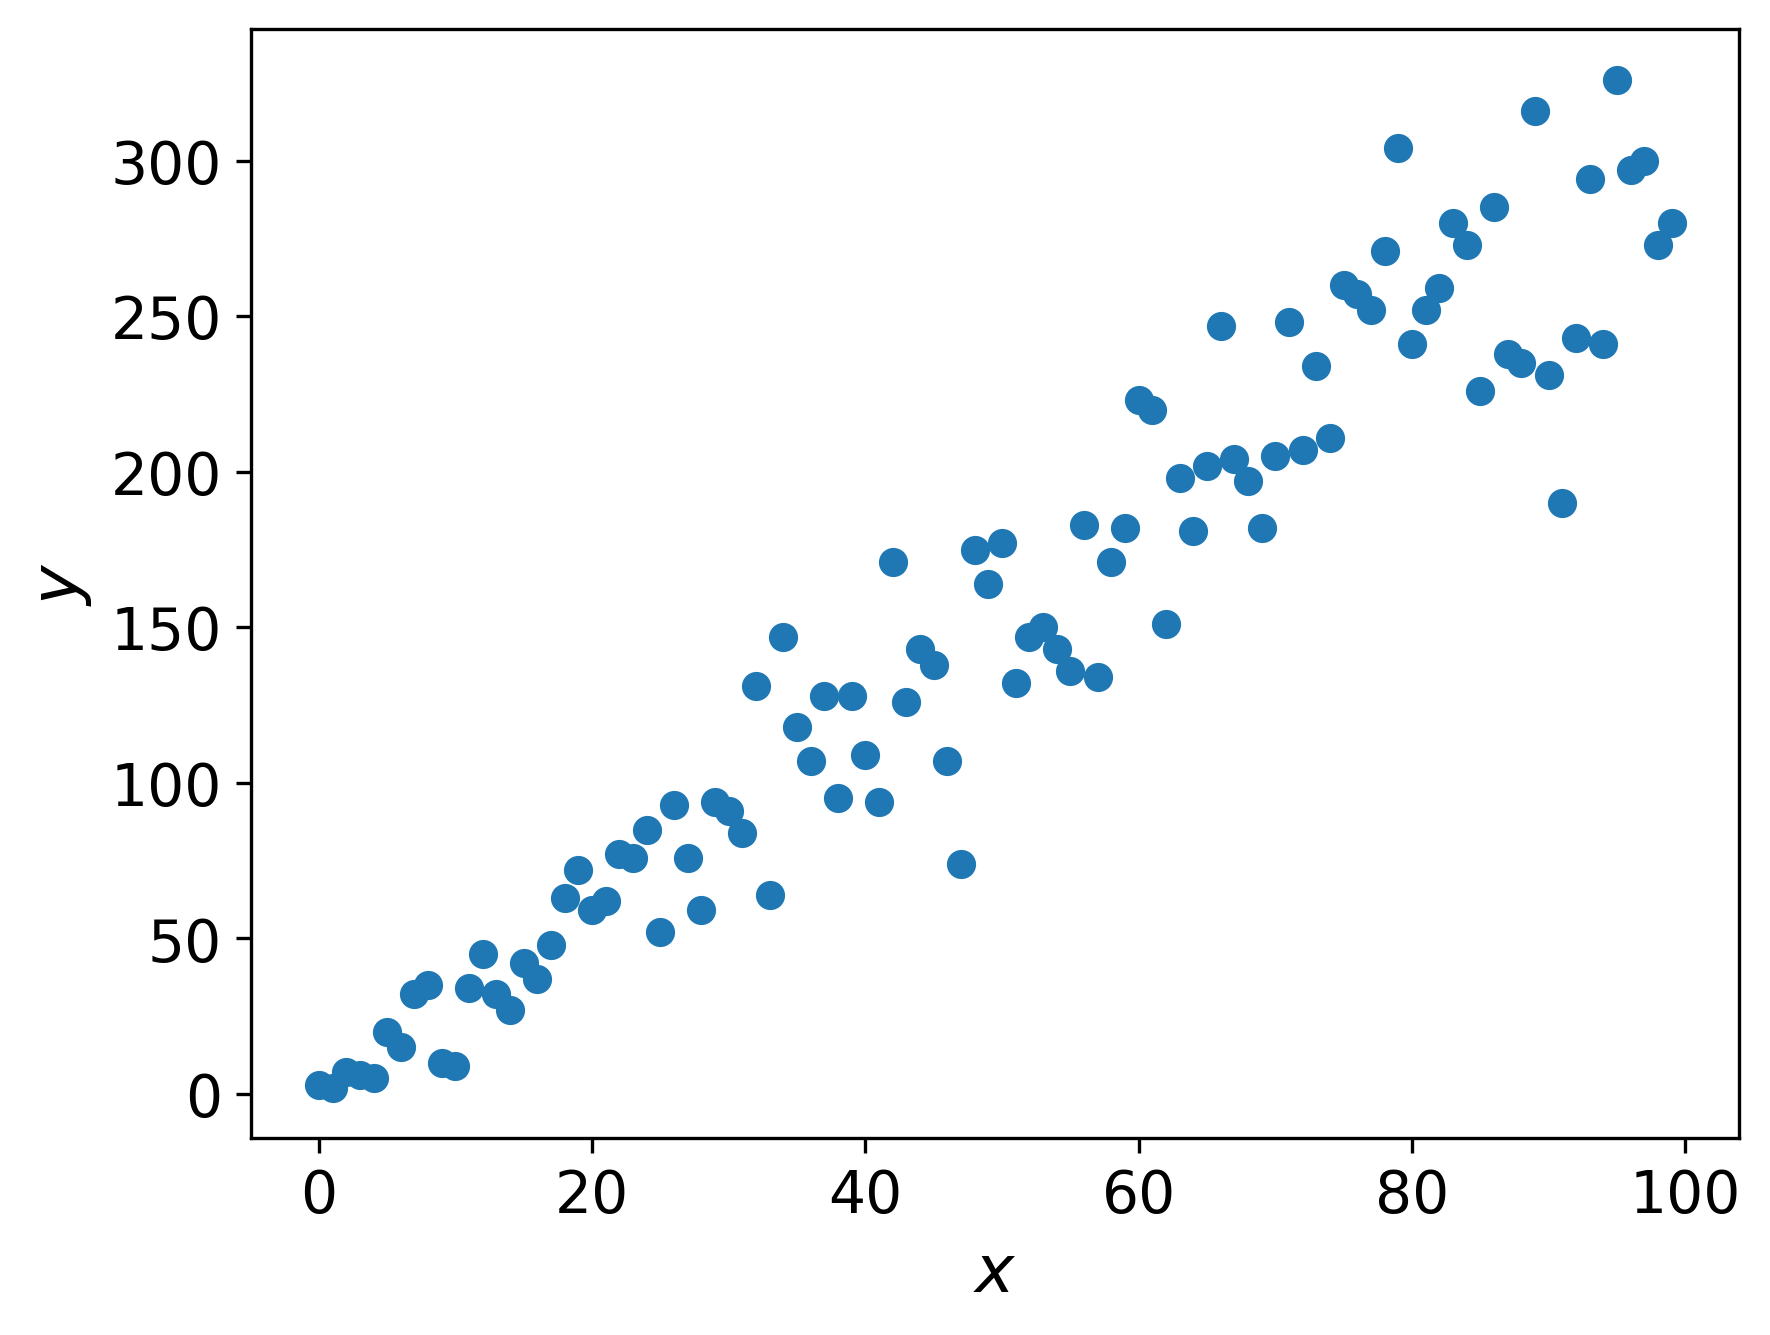

In [ ]:
#Let's take a look!
fig1 = plt.figure()
plt.scatter(x, y)
plt.xlabel('$x$')
plt.ylabel('$y$')

#### Here comes the linear regression model ;) 

In [ ]:
model = linear_model.LinearRegression()
model

LinearRegression()

I can fit the model (right now, I will do it using the entire data set just to compare with the analytic solution). When only one predictor is present, I need to reshape it to column form.

In [ ]:
print(x)
X = x.reshape(-1,1) # rows, columns;row = -1 used if there is a single feature
print(X[:10]) # show first 10 rows
model.fit(X,y) 

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]


LinearRegression()

The fitted model has attributes "coef_", "intercept_":

In [ ]:
slope, intercept = model.coef_, model.intercept_
print(slope, intercept)

[3.02475848] -0.12554455445541635


Remember the "true" answer is 3, 3.

We can plot the original and the fitted line.

Text(0, 0.5, '$y$')

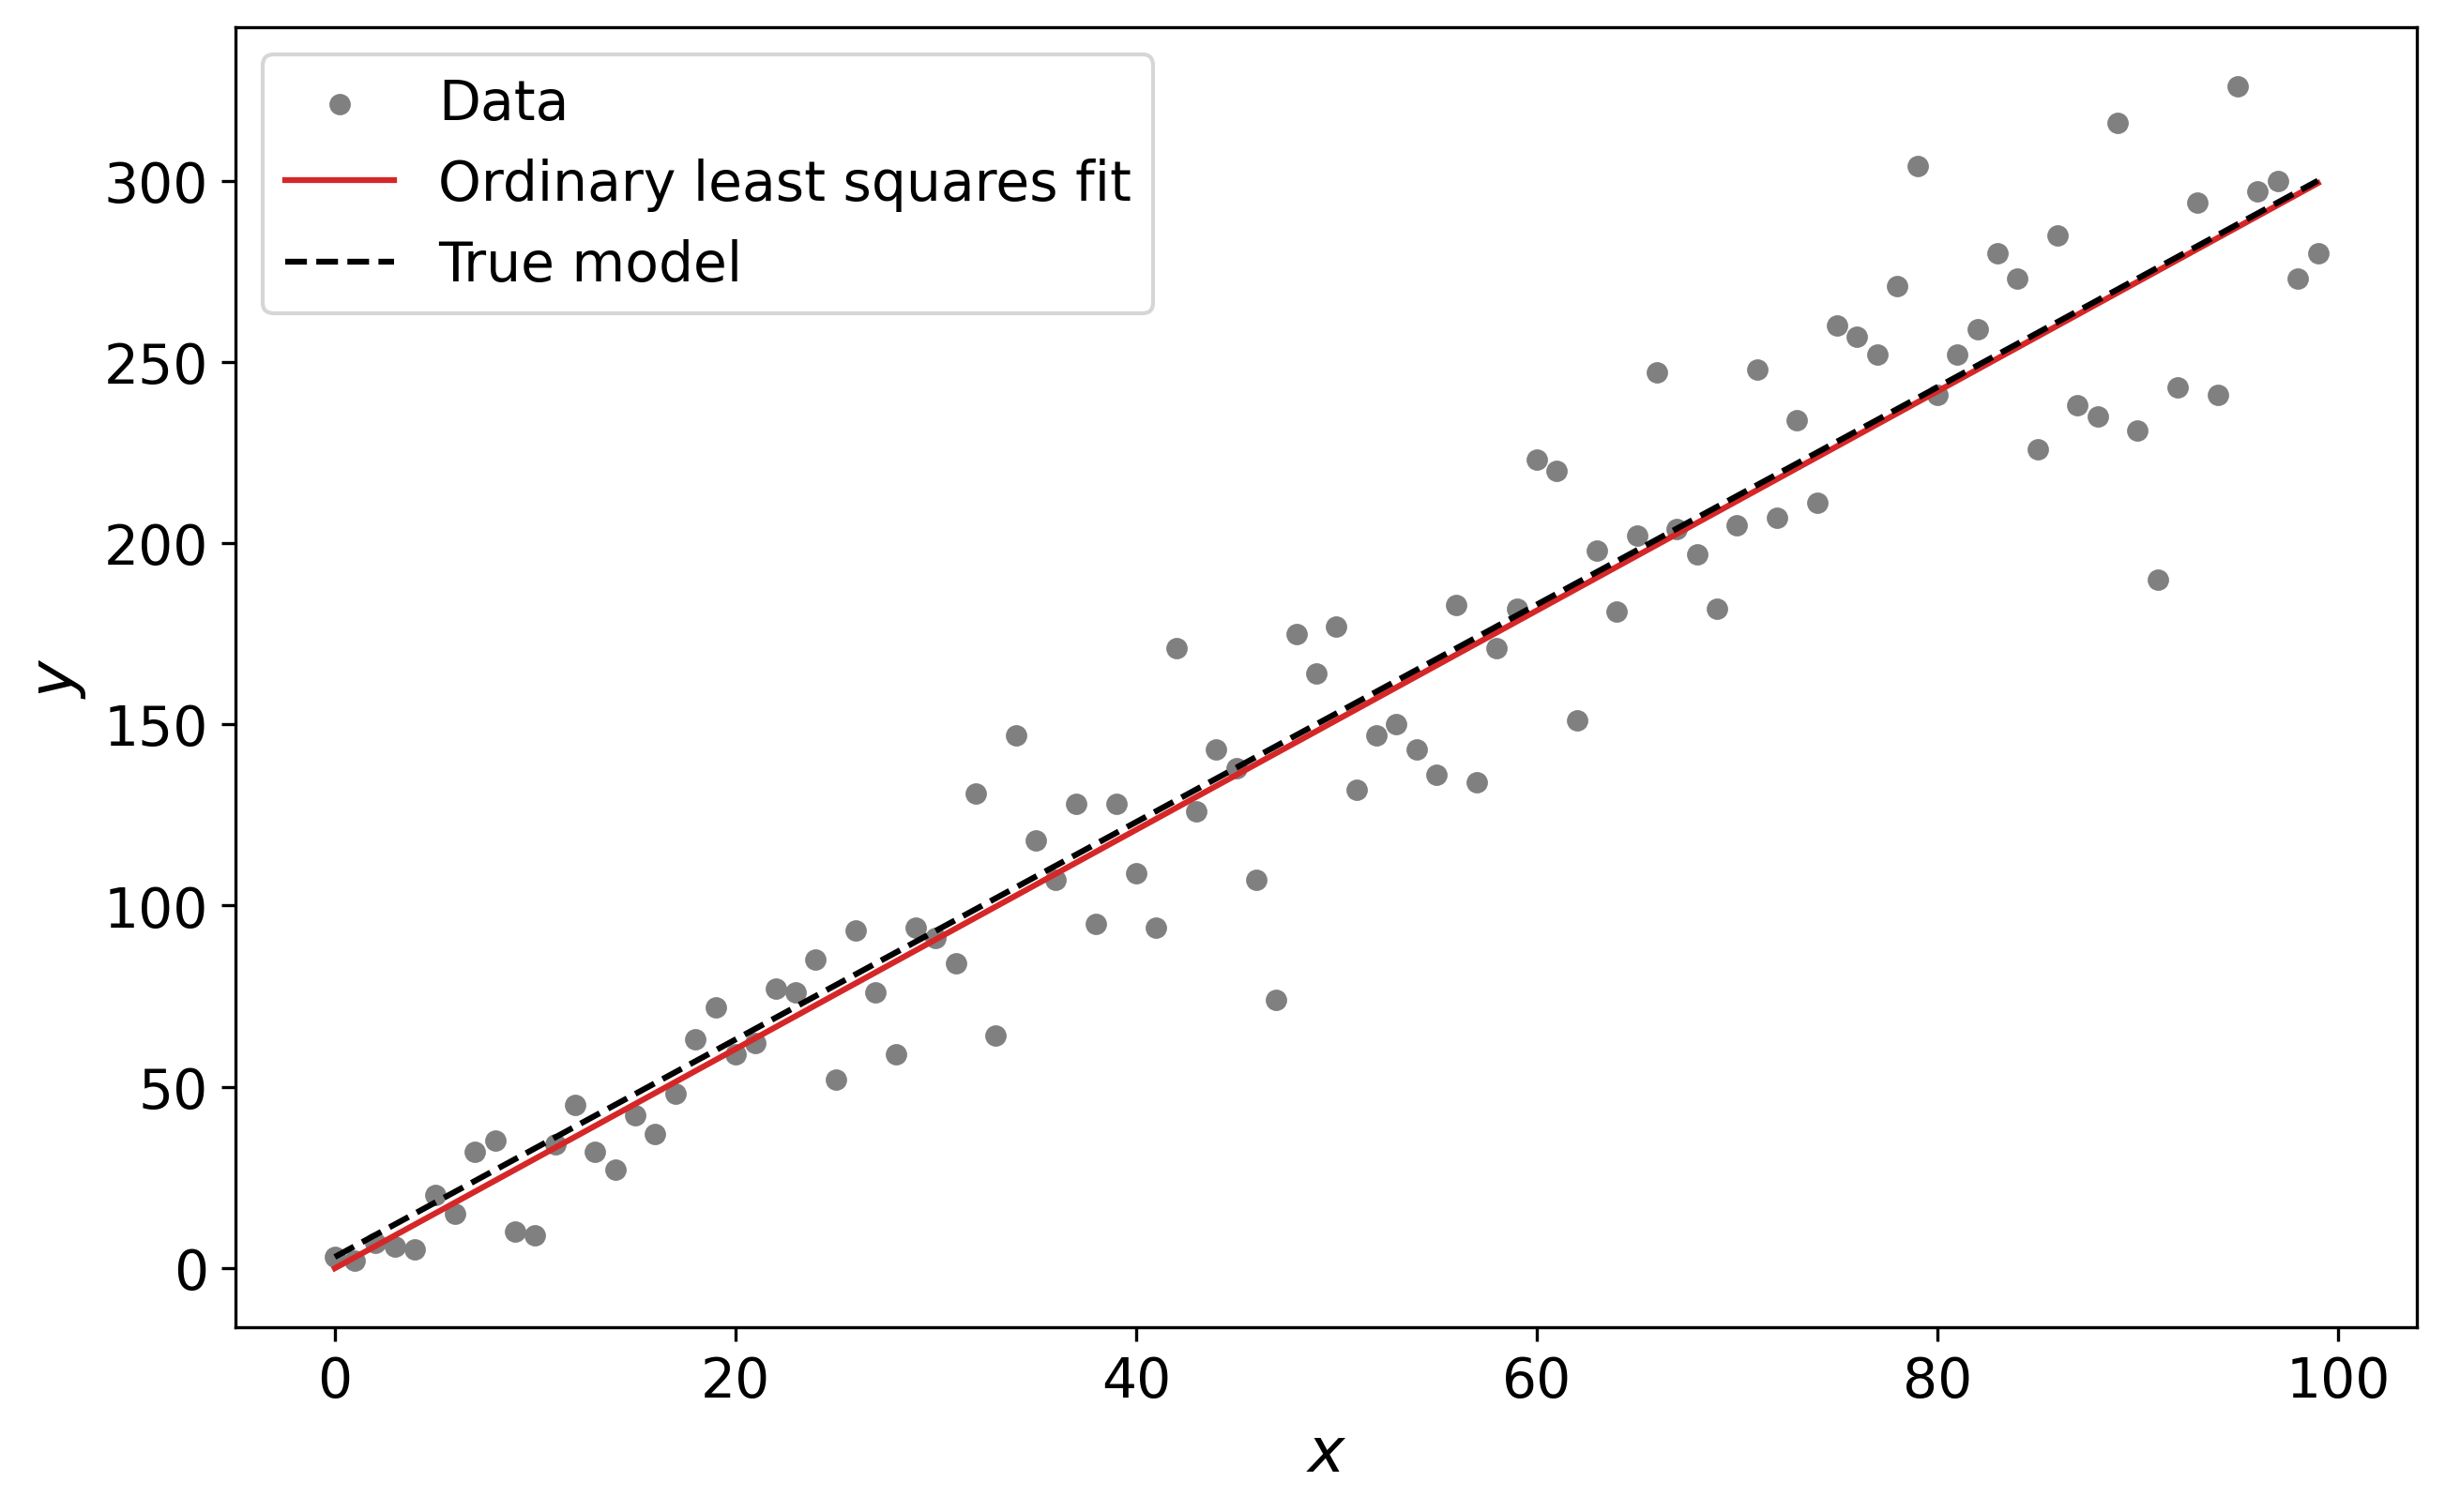

In [ ]:
fig2 = plt.figure(figsize = (10,6))
plt.scatter(X,y, s = 20, c = 'gray', label = 'Data')
plt.plot(X, slope*X + intercept, c='C3', label = 'Ordinary least squares fit')
plt.plot(X, 3*X + 3, '--', c ='k', label = 'True model')
plt.legend(fontsize = 14)
plt.xlabel('$x$')
plt.ylabel('$y$')

What are the analytic predictions for the coefficients?  $(\beta_0,\beta_1)$

In [ ]:
#Predictions - fill in the analytic formula

beta1 = np.sum((x - np.mean(x))*(y - np.mean(y)))/np.sum((x - np.mean(x))*(x - np.mean(x)))

beta0 = np.mean(y) - beta1*np.mean(x)

In [ ]:
print('beta_0, beta_1:', beta0, beta1)

beta_0, beta_1: -0.12554455445544477 3.0247584758475847


I can also obtain the second one in the variance/covariance notation (note: a small difference is due to 1/n vs 1/(n-1) in the definition; use bias = True for consistency).

In [ ]:
print('Sample Cov / Sample var:', np.cov(x,y, bias=True)[0,1]/np.var(x))

Sample Cov / Sample var: 3.0247584758475843


#### We can (and should!) do cross validation and all the nice things we have learned to do for classification problems.

In [ ]:
cv = KFold(n_splits = 5 , shuffle = True , random_state = 10)

In [ ]:
scores = cross_validate(model, X, y, cv = cv, return_train_score = True)
scores

{'fit_time': array([0.00040889, 0.00024891, 0.00022769, 0.0002203 , 0.00023413]),
 'score_time': array([0.00027108, 0.00020719, 0.00019026, 0.00018382, 0.00018477]),
 'test_score': array([0.9165209 , 0.89174158, 0.94218009, 0.84836725, 0.94721595]),
 'train_score': array([0.92686135, 0.92950195, 0.91582181, 0.93664738, 0.91668227])}

In [ ]:
print('Test R^2 scores:', '{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train R^2 scores:', '{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

Test R^2 scores: 0.909 0.036
Train R^2 scores: 0.925 0.008


### Questions: 

- What are the scores that are being printed out?

- How are the scores? 

- Does it suffer from high variance? High bias?

- What would happen to the scores if we increased the scatter (noise)?

### <font color='green'> Scoring in regression problems. </font>

### Here is a way to visualize all the available scorers.

In [ ]:
#print(sorted(sklearn.metrics.SCORERS.keys())) # does not work
print(sorted(sklearn.metrics.get_scorer_names()))

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

### Do you recognize some of them?

Let's see if we can find the MSE.

In [ ]:
scores = cross_validate(model, X, y, cv = cv, scoring = 'neg_mean_squared_error', return_train_score = True, return_estimator = True)
slopes, intercepts = [], []
for mod in scores['estimator']:
    slopes.append(mod.coef_)
    intercepts.append(mod.intercept_)
print('slope = %.3f +/- %.3f, intercept = %.3f +/- %.3f' % (np.mean(slopes),np.std(slopes),np.mean(intercepts),np.std(intercepts)))
print('Test scores:','{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train scores:','{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

slope = 3.025 +/- 0.060, intercept = -0.104 +/- 2.571
Test scores: -668.738 174.422
Train scores: -612.142 38.181


Something to note is that estimators of performance of the "error" type (in other words, the lower, the better) receive a negative sign in sklearn. This is just to maintain consistency with the "higher score = better" framework.

Can also try the Mean Absolute Error:

In [ ]:
scores = cross_validate(model, X, y, cv = cv, scoring = 'neg_mean_absolute_error', return_train_score = True)
print('Test scores:','{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train scores:','{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

Test scores: -19.461 1.948
Train scores: -18.925 0.580


Finally, by plotting the residuals, we can see that they are not independent of x (the assumptions of the probabilistic linear model are not satisfied). But that doesn't mean we can't create a model.

Text(0, 0.5, 'residuals $(\\hat{y}-y)$')

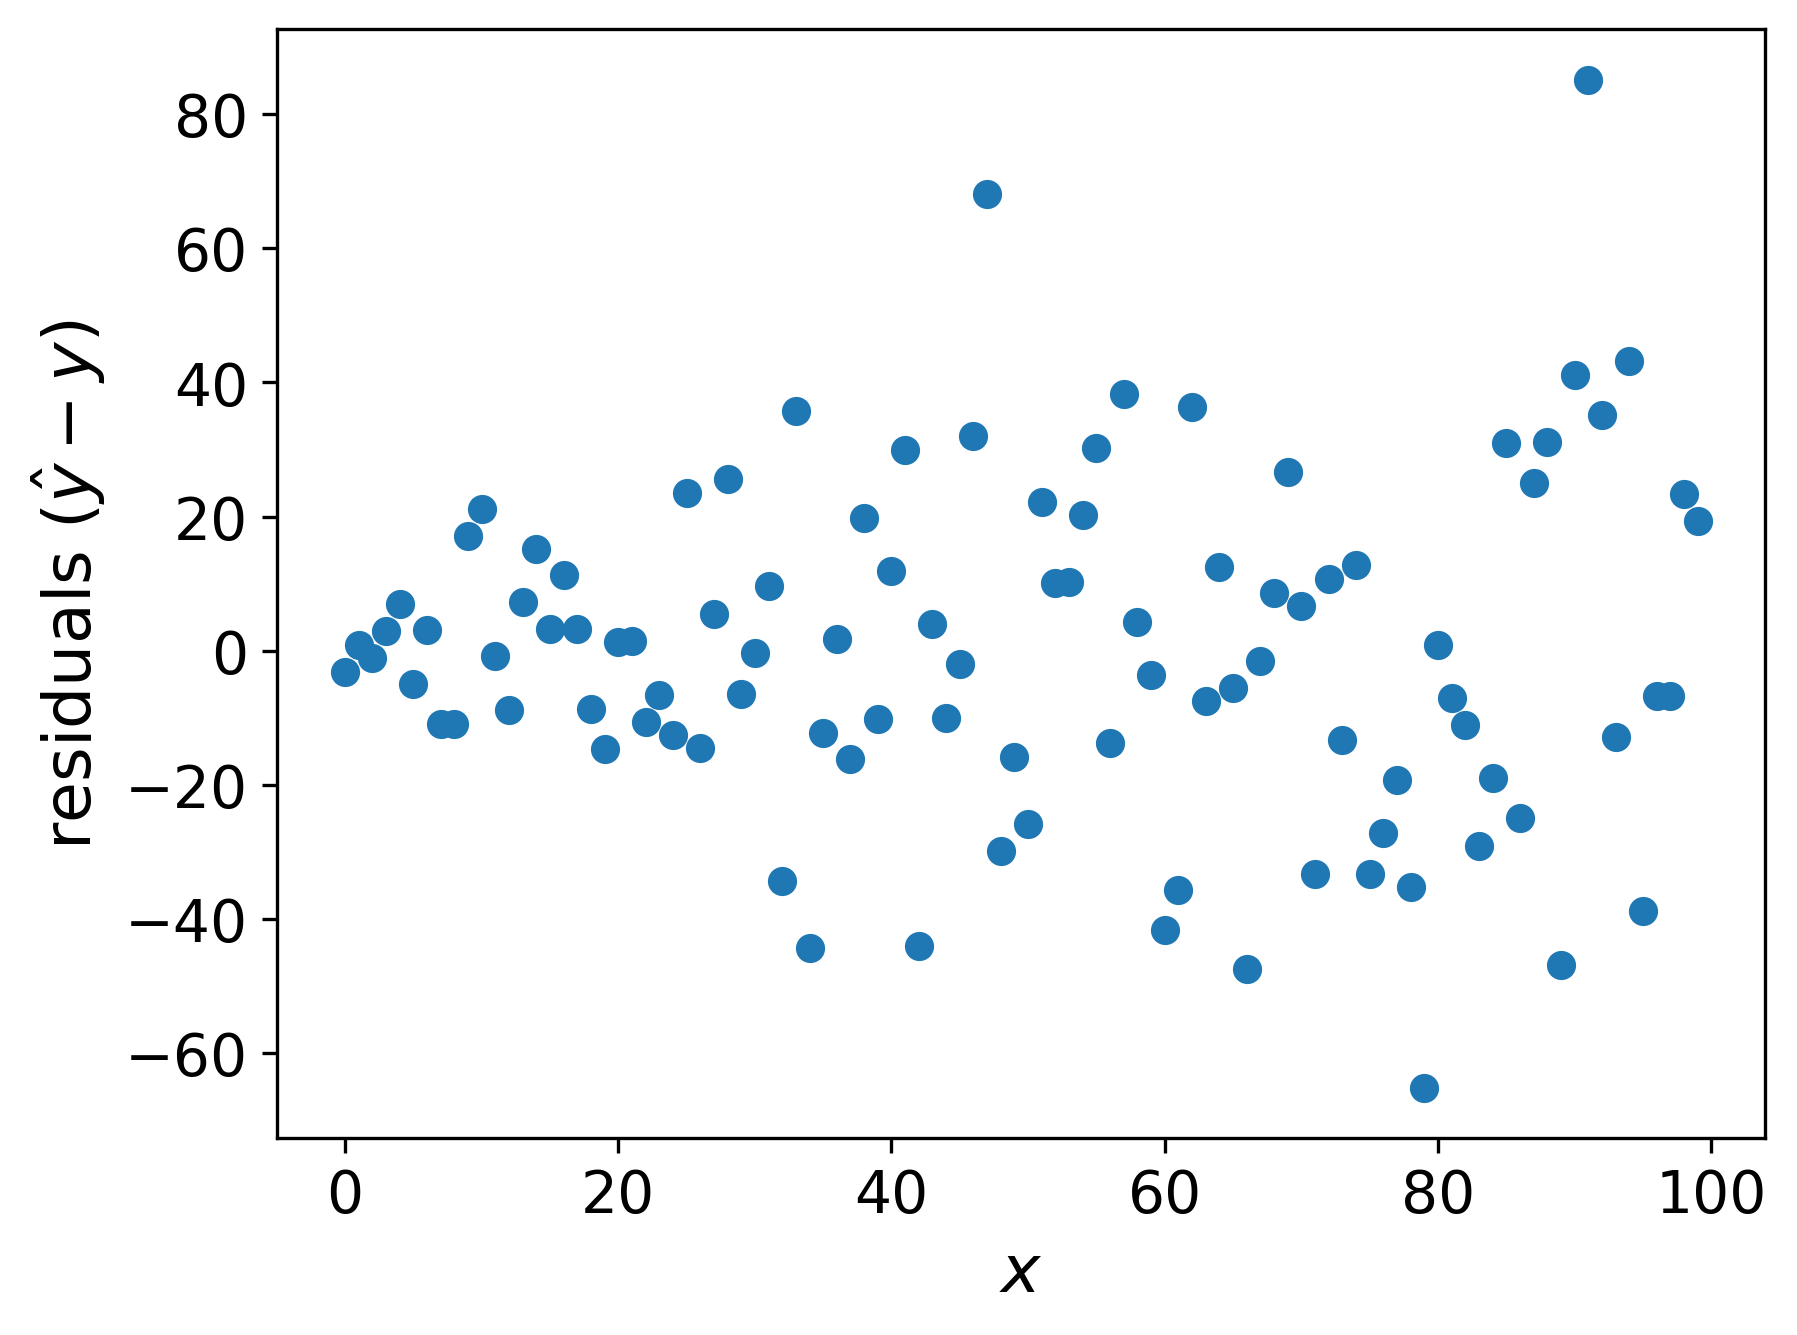

In [ ]:
fig3 = plt.figure()
#plt.scatter(x, slope*x + intercept - y, color = 'b', label = 'Residuals')
plt.scatter(x, slope*x + intercept - y)
plt.xlabel('$x$')
plt.ylabel('residuals $(\\hat{y}-y)$')
#plt.legend();

### Custom scores

We might like to implement a scorer where we care about percentage error instead. Here is how to do a custom scorer:

In [ ]:
from sklearn.metrics import make_scorer

In [ ]:
def mape(true,pred): #Modified Mean Absolute Percentage Error
    return np.mean(np.abs(true-pred)/(0.5*(true+pred)))

mape_scorer = make_scorer(mape, greater_is_better = False)

In [ ]:
scores = cross_validate(model, X, y, cv = cv, scoring = mape_scorer, return_train_score = True)
scores

{'fit_time': array([0.00046182, 0.00058532, 0.00036025, 0.00027895, 0.00026226]),
 'score_time': array([1.36137009e-04, 1.69992447e-04, 9.77516174e-05, 8.79764557e-05,
        8.29696655e-05]),
 'test_score': array([-0.20708215, -0.16840171, -0.1728769 , -0.15332491, -0.20178944]),
 'train_score': array([-0.1789928 ,  0.38976175, -0.19881487, -0.40769513, -0.18684556])}

In [ ]:
print('Test scores:','{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train scores:','{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

Test scores: -0.181 0.021
Train scores: -0.117 0.267


#### Note: as we already discussed, so far we have not changed the loss function (MSE), or the coefficients of the model. We have only looked at different evaluation metrics.

#### <font color = 'green'> Question 1: would the best fit line change if we optimize a different loss function? </font>

Yes!

#### <font color = 'green'> Question 2: How can we implement that without an analytic solution? </font>

For example, with a Grid Search.


This is an example using the Mean Square Error.

In [ ]:
beta0 = np.linspace(-5,5,200)
beta1 = np.linspace(2.7,3.3,200)

In [ ]:
mse = np.empty((200,200))

N = len(y)
for i,b0 in enumerate(beta0):
    for j,b1 in enumerate(beta1):
        mse[i,j] = np.sum((b0 + b1*x - y)**2)/N

Text(0, 0.5, '$\\beta_1$')

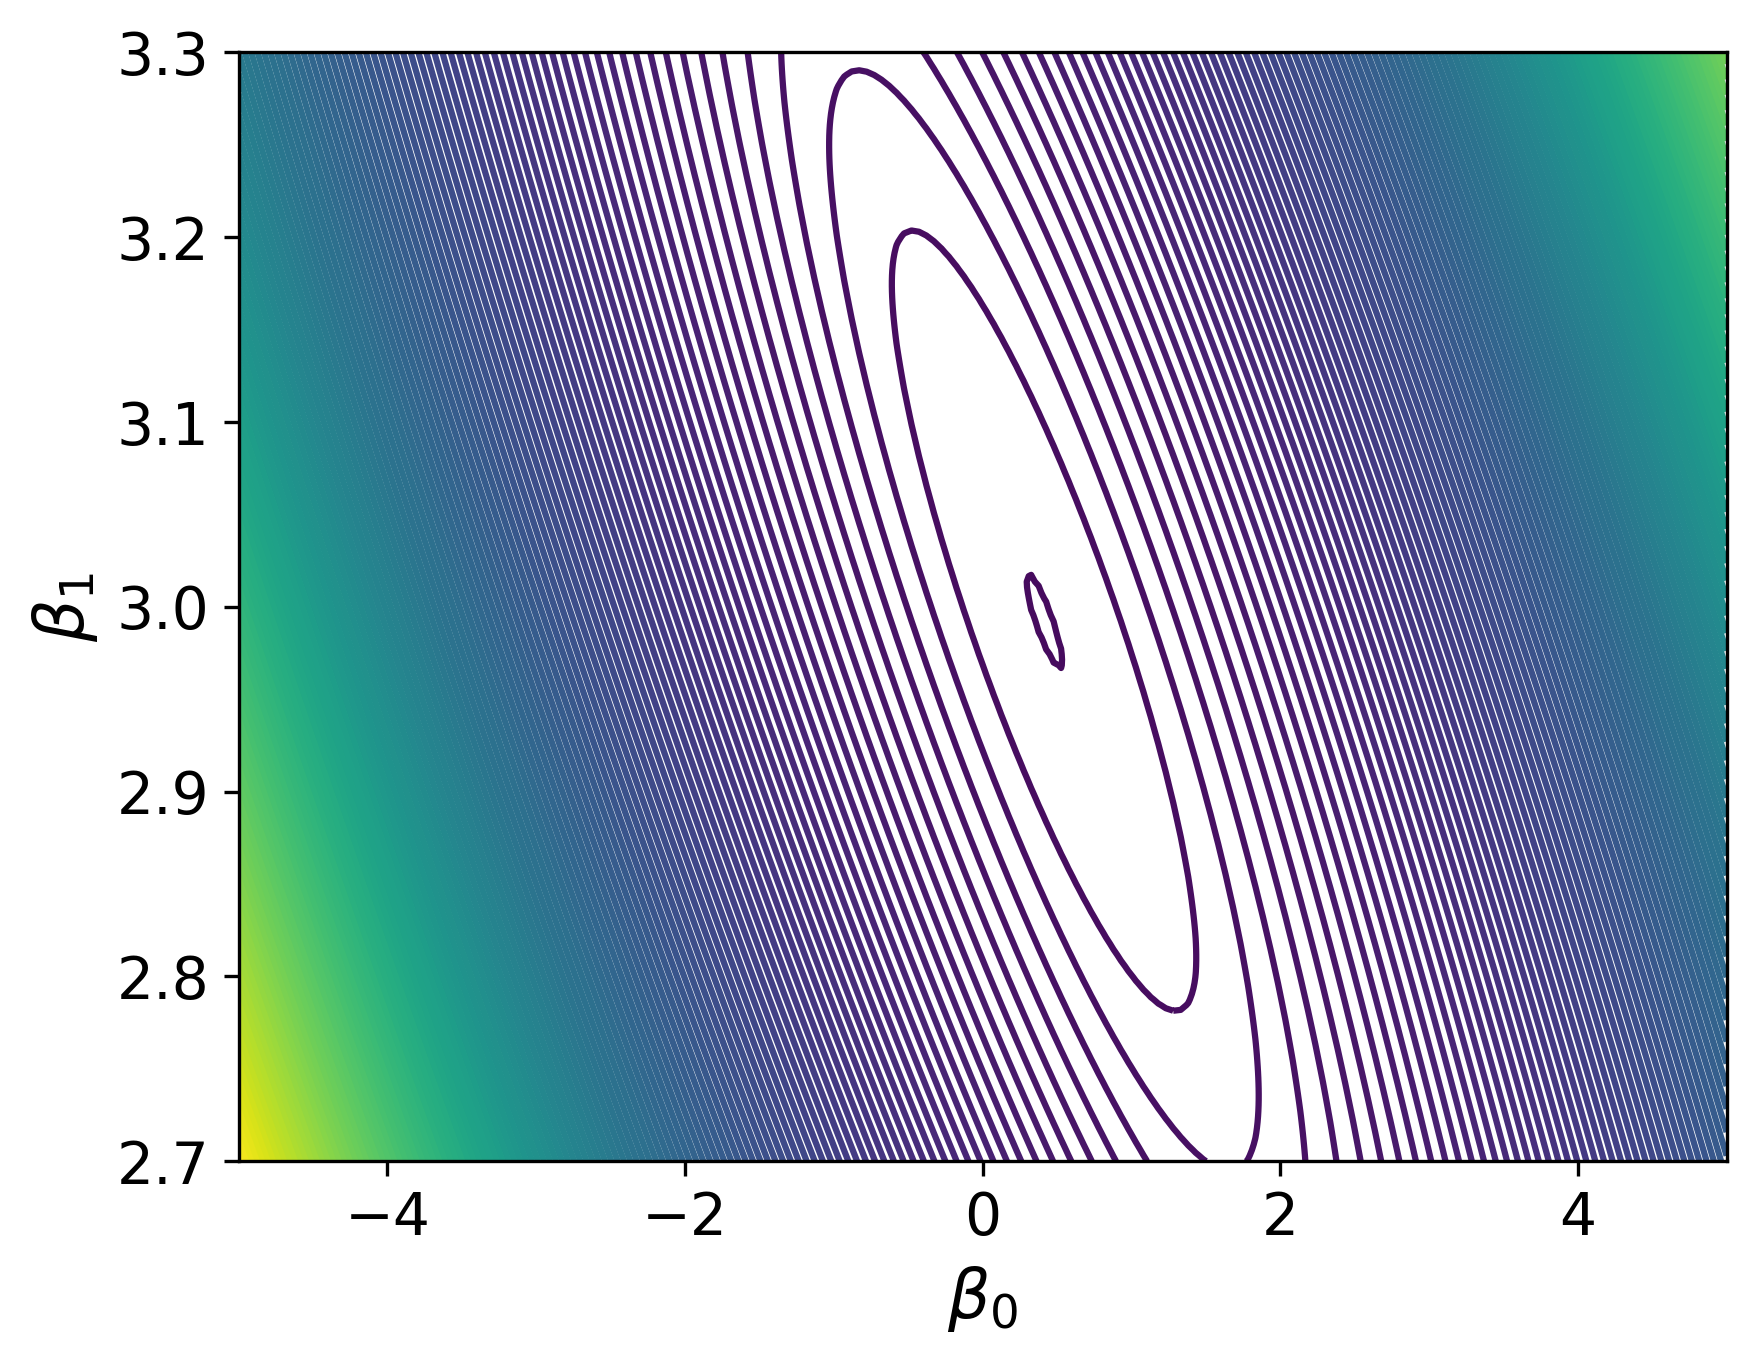

In [ ]:
fig4, ax = plt.subplots()
levels = np.logspace(2.78,3.06,130)
CS = ax.contour(beta0, beta1, mse, levels)
#print(CS.levels)
plt.xlabel('$\\beta_0$')
plt.ylabel('$\\beta_1$')

Text(0.5, 0, 'MSE')

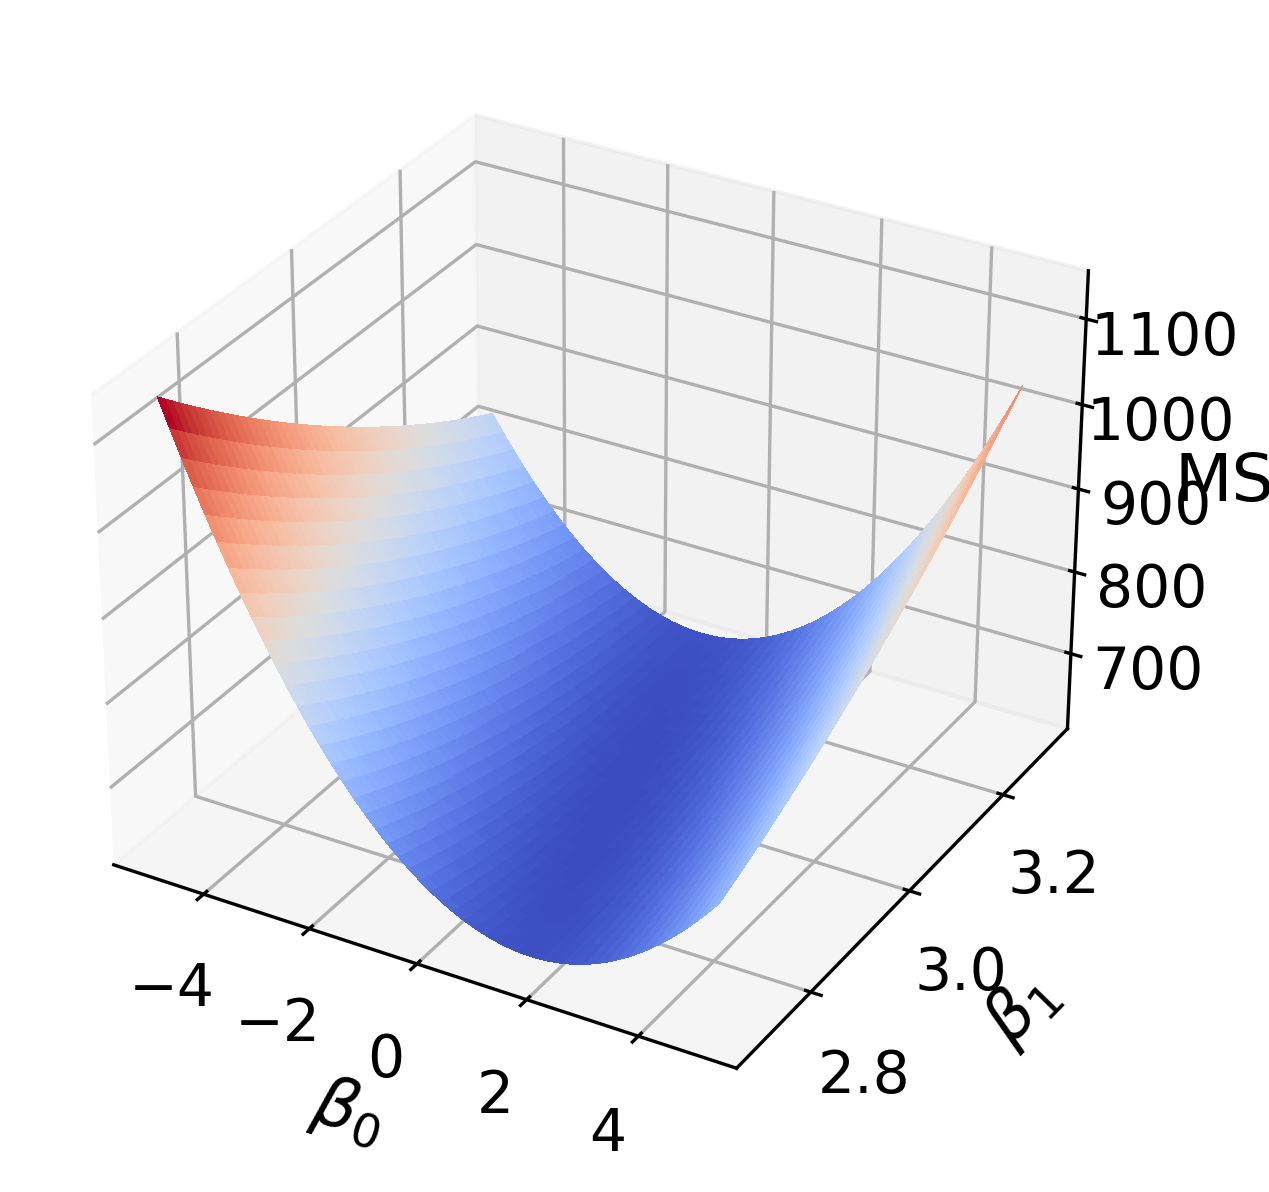

In [ ]:
fig5, ax = plt.subplots(subplot_kw={"projection": "3d"})
b0, b1 = np.meshgrid(beta0,beta1)
surf = ax.plot_surface(b0, b1, mse, cmap=matplotlib.cm.coolwarm, linewidth=0, antialiased=False)
plt.xlabel('$\\beta_0$')
plt.ylabel('$\\beta_1$')
ax.set_zlabel('MSE')

To get the indices of the 2D array, I need to unravel it

In [ ]:
besti, bestj = np.unravel_index(mse.argmin(), mse.shape)
print(besti, bestj)

96 108


I can now find the minimum MSE (not very informative, TBH) and the best fit coefficients:

In [ ]:
mse[besti,bestj]

np.float64(617.7599159364663)

In [ ]:
beta0[besti], beta1[bestj]

(np.float64(-0.17587939698492416), np.float64(3.0256281407035175))

Question: How do they compare to the ones found by the Linear Model / analytic ones? .... 

It will be interesting to see what happens to the parameters if we use a different loss function (MAE, MAPE, Huber loss).

However, because these data are so regular, it's kind of boring, so before trying the different losses let's inject some outliers in the data.

### What happens when we add outliers?

In [ ]:
np.random.seed(12) #set 
out = np.random.choice(100,15) #select 15 outlier indices
y_wo = np.copy(y)
np.random.seed(12) #set again
y_wo[out] = y_wo[out] + 5*np.random.rand(15)*y[out]

Text(0, 0.5, '$y$')

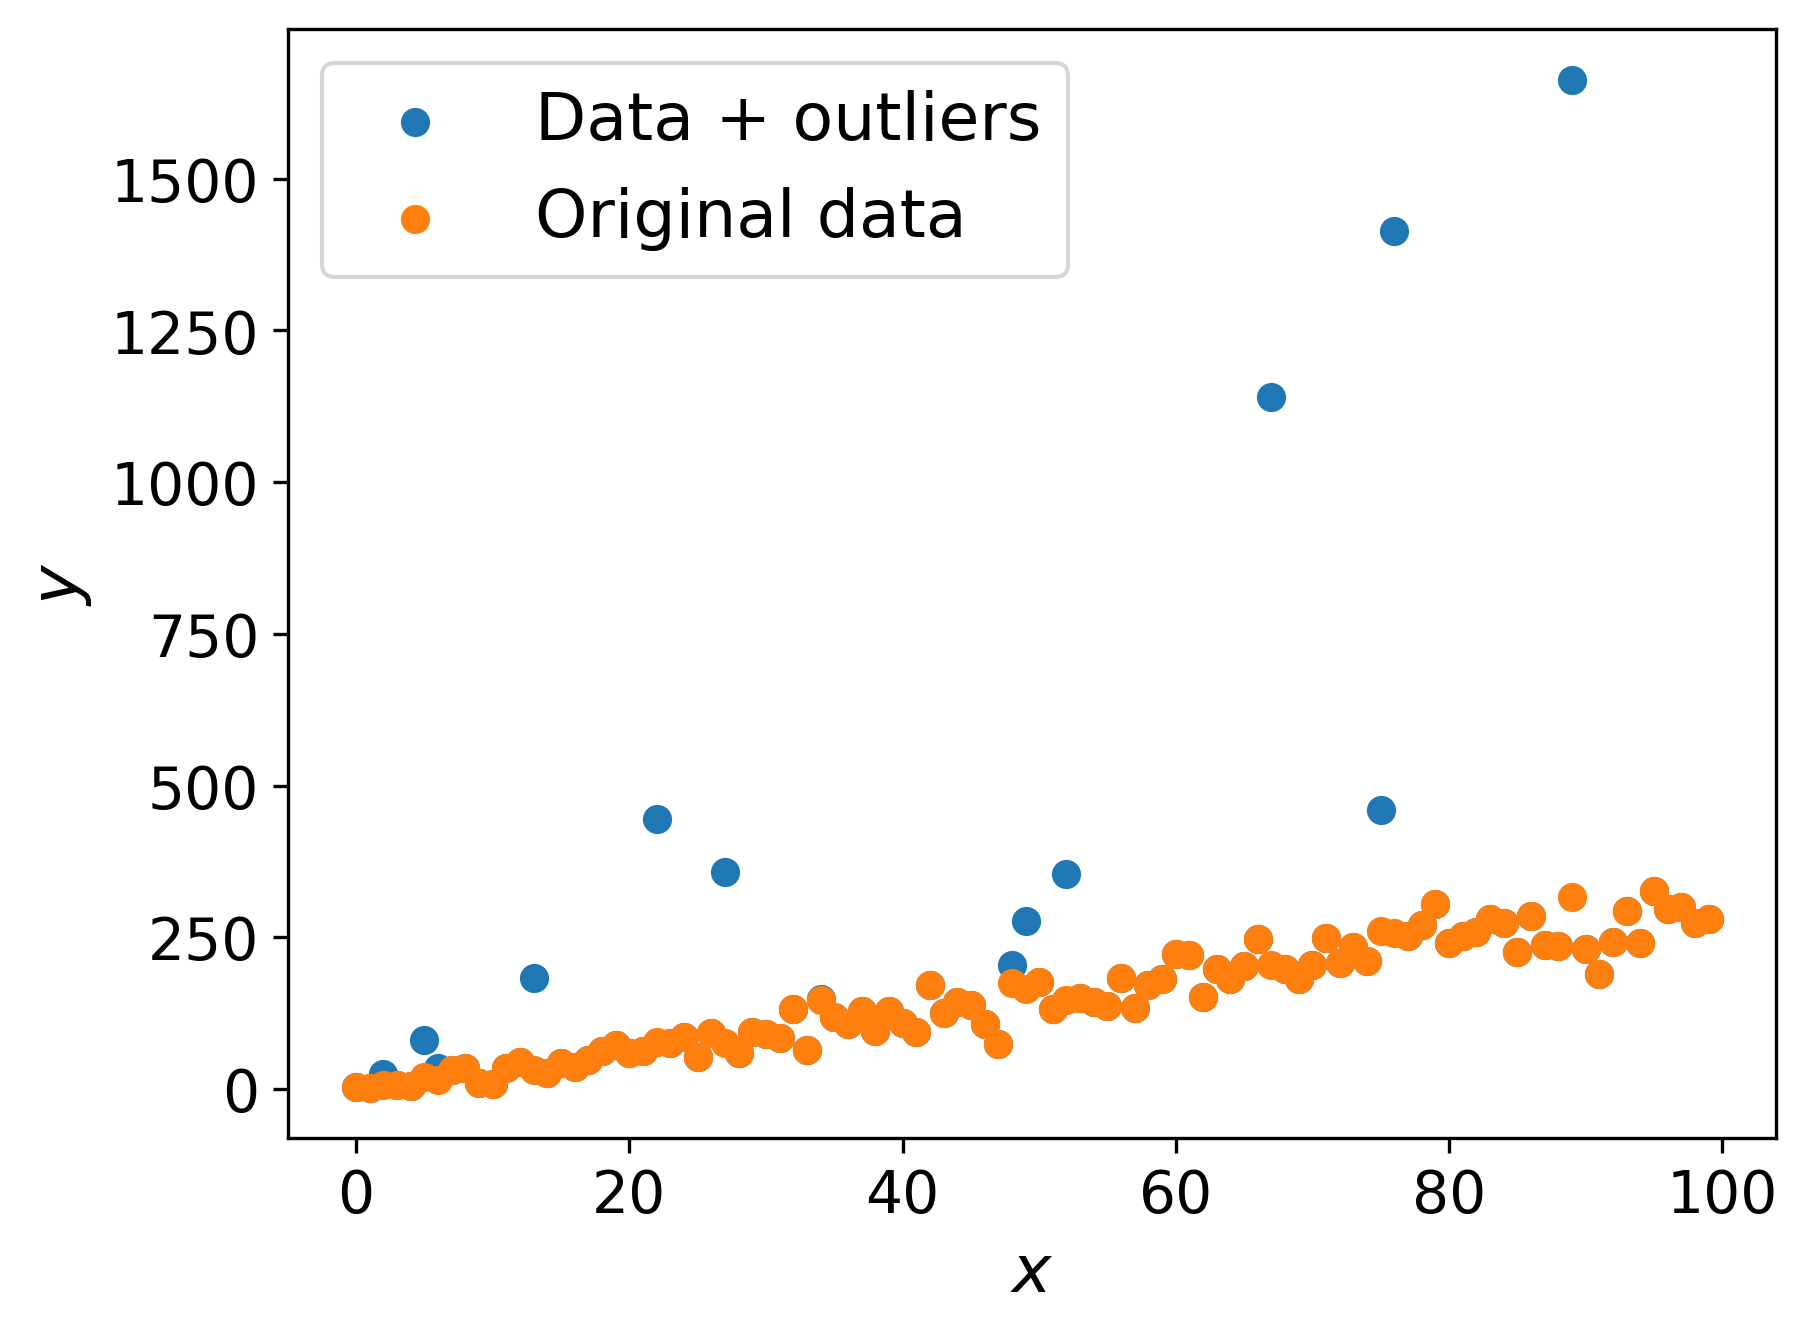

In [ ]:
fig5 = plt.figure()
plt.scatter(x,y_wo, label = 'Data + outliers')
plt.scatter(x,y, label = 'Original data')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$y$')

We can see the effect for the MSE loss right away:

In [ ]:
model.fit(X,y_wo)
y_pred = model.predict(X)
MSE = metrics.mean_squared_error(y_wo, y_pred)
slope, intercept, score = model.coef_, model.intercept_, model.score(X,y_wo) # the only option for score here is R^2
print(slope, intercept, MSE, score)

[3.97842184] 1.5481188118812383 43259.081624722465 0.23364219310419954


In [ ]:
scores = cross_validate(model, X, y_wo, cv = cv, scoring = 'neg_mean_squared_error', return_estimator = True, return_train_score = True)
slopes, intercepts = [], []
for mod in scores['estimator']:
    slopes.append(mod.coef_)
    intercepts.append(mod.intercept_)
#print(slopes)
#print(intercepts)
print('slope = %.3f +/- %.3f, intercept = %.3f +/- %.3f' % (np.mean(slopes),np.std(slopes),np.mean(intercepts),np.std(intercepts)))
print('Test scores:','{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train scores:','{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

slope = 3.991 +/- 0.457, intercept = 1.403 +/- 18.610
Test scores: -45271.504 31660.135
Train scores: -43034.304 7830.667


Text(0, 0.5, '$y$')

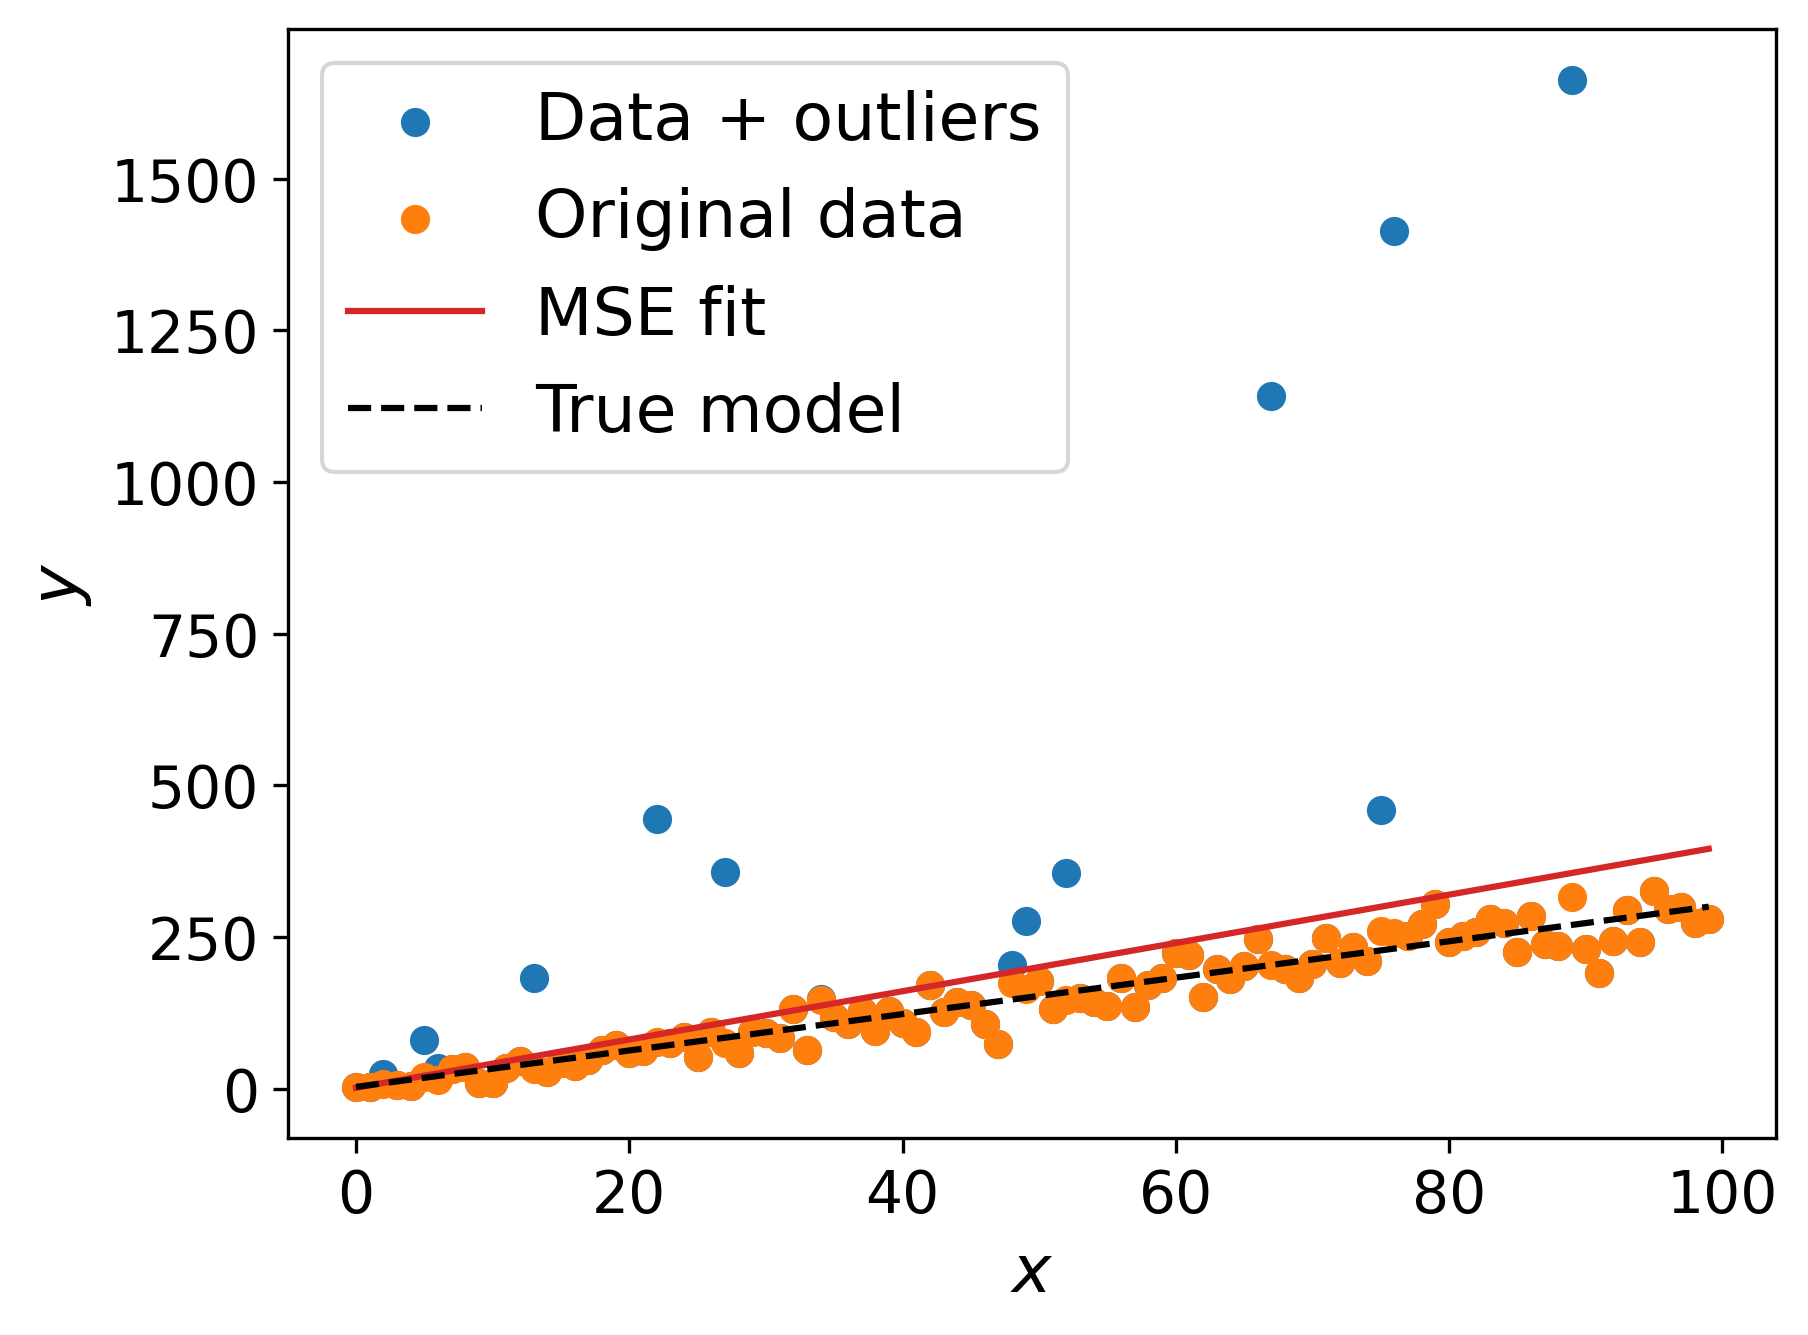

In [ ]:
fig6 = plt.figure()
plt.scatter(x,y_wo, label = 'Data + outliers')
plt.scatter(x,y, label = 'Original data')
plt.plot(X, slope*X + intercept, c='C3', label = 'MSE fit')
plt.plot(X, 3*X + 3, '--', c ='k', label = 'True model')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$y$')

### Exercise: 

1. Calculate the best fitting coefficients (e.g. using a grid, like the one we made in the previous example) for the MSE, MAE and modified MAPE, and Huber loss.

2. Plot the data and the four best fits.

3. Explain the results by commenting on the differences.

Note: the Huber loss is a hybrid between MSE and MAE (behaves like MAE when the error is larger than a certain amount, often called delta, so it's less sensitive to outliers). One possibility is to use the std of the y values to set delta.